# Predicción del precio de venta de vehículos usados

**Proyecto Integrador — Modelos y Simulación de Sistemas I (Grupo B, Universidad de Antioquia)**
Docente: Andrés Parra · **Fase 1 — Modelo predictivo**

| | |
|---|---|
| **Integrantes** | _Jonathan Mazo González, Juan Carlos Gómez Jaramillo_ |
| **Repositorio** | _(URL de GitHub)_ |
| **Fecha de entrega** | 15 de septiembre de 2026 |

> Este notebook es ejecutable de principio a fin sin intervención manual
> (`Kernel → Restart & Run All`). Toda decisión de preparación de datos se
> justifica en el texto y todo ajuste (imputación, codificación) se realiza
> **solo con datos de entrenamiento** mediante un `Pipeline` de scikit-learn.

## 1. Introducción

**Problema.** En el mercado de vehículos usados el precio de venta lo fija cada
vendedor de forma manual y heterogénea. Un modelo que estime el precio a partir
de las características objetivas del vehículo sirve como referencia tanto para
quien vende (fijar un precio competitivo) como para quien compra (detectar
sobreprecios).

**Objetivo del modelo.** Predecir el precio de venta (`price`, en dólares) de un
vehículo usado a partir de sus atributos: marca, año, kilometraje, tipo de
combustible, especificaciones de motor, transmisión, colores, historial de
accidentes y estado del título.

**Tipo de problema.** Aprendizaje supervisado, **regresión** (la variable
objetivo es cuantitativa continua).

**Variable objetivo.** `price` — precio de venta publicado, en dólares
estadounidenses. En el archivo original viene como texto (`"$10,300"`) y se
convierte a numérico durante la preparación.

**Fuente de datos.** *Used Car Price Prediction Dataset*, Kaggle
(https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset).
Corte transversal: cada fila es un vehículo listado en un momento dado; **no es
una serie temporal**. El archivo se versiona en el repositorio en
`fase-1/data/used_cars.csv`.

## 2. Configuración del entorno

Fijamos una semilla global (`RANDOM_STATE = 42`) que se reutiliza en la
separación train/test y en todos los estimadores con componente aleatoria, para
que el notebook sea reproducible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("Versiones — pandas", pd.__version__, "| numpy", np.__version__,
      "| scikit-learn", __import__("sklearn").__version__)

Versiones — pandas 2.2.3 | numpy 2.2.4 | scikit-learn 1.7.2


In [2]:
# El notebook funciona tanto si se ejecuta desde fase-1/ como desde la raíz del repo.
DATA_PATH = Path("data/used_cars.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("fase-1/data/used_cars.csv")

if not DATA_PATH.exists():
    import kagglehub
    kaggle_dir = Path(kagglehub.dataset_download("taeefnajib/used-car-price-prediction-dataset"))
    DATA_PATH = next(kaggle_dir.glob("*.csv"))

df = pd.read_csv(DATA_PATH)
print("Archivo:", DATA_PATH.resolve())
print("Dimensiones:", df.shape)

assert df.shape == (4009, 12), (
    f"El dataset descargado tiene forma {df.shape}, distinta a la esperada (4009, 12). "
    "Es posible que Kaggle haya publicado una versión nueva — revisa el EDA antes de continuar."
)

df.head()

Archivo: E:\UDEA\2026-2\Modelos I\proyecto-modelos-simulacion\fase-1\data\used_cars.csv
Dimensiones: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 3. Descripción del dataset

- **Observaciones:** 4 009 vehículos (filas).
- **Variables:** 12 columnas $\rightarrow$ 11 predictoras potenciales + la variable objetivo.
- **Unidad de observación:** un vehículo publicado. Corte transversal, sin
  componente temporal.
- **Variable obejetivo:** `price` representa el precio de venta listado del vehiculo, en dólares, es de aclarar que es el precio publicado, no necesariamente el precio final de transacción negociado.

**Partimos de las 12 columnas originales.** Ninguna se descarta de entrada;
cualquier eliminación se justifica más adelante, durante el análisis.

| Columna | Tipo | Descripción | Observaciones iniciales |
|---|---|---|---|
| `brand` | categórica | Marca | 57 categorías |
| `model` | categórica | Modelo | **1 898 categorías** (cardinalidad muy alta) |
| `model_year` | numérica | Año de fabricación | rango 1974–2024 |
| `milage` | texto→numérica | Kilometraje | viene como `"51,000 mi."` |
| `fuel_type` | categórica | Combustible | nulos + valores corruptos (`-`, `not supported`) |
| `engine` | texto | Especificaciones del motor | texto libre; se puede extraer HP, litros, cilindros |
| `transmission` | categórica | Transmisión | 62 variantes de texto |
| `ext_col` | categórica | Color exterior | 319 categorías |
| `int_col` | categórica | Color interior | 156 categorías |
| `accident` | categórica | Historial de accidentes | binaria + nulos |
| `clean_title` | categórica | Título limpio | solo aparece el valor `"Yes"` + nulos |
| `price` | texto→numérica | **Precio de venta (objetivo)** | viene como `"$10,300"` |

**Limitaciones conocidas del dataset.**

1. No incluye ubicación geográfica ni fecha de publicación, factores que influyen
   en el precio real y que aquí quedan como ruido no explicado.
2. `price` está fuertemente sesgado a la derecha: coexisten autos de uso masivo
   con vehículos de colección de cientos de miles a millones de dólares.
3. Alta cardinalidad en `model`, `ext_col`, `int_col`.
4. Valores faltantes en `fuel_type`, `accident` y `clean_title` (se cuantifican
   en el EDA).

## 4. Análisis exploratorio (EDA)

### 4.1 Valores faltantes

,n_nulos,pct_nulos
clean_title,596,14.87
fuel_type,170,4.24
accident,113,2.82
brand,0,0.00
milage,0,0.00
model_year,0,0.00
model,0,0.00
engine,0,0.00
ext_col,0,0.00
transmission,0,0.00


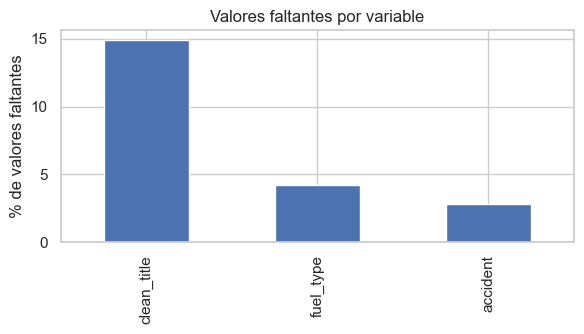

In [3]:
nulos = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
})
nulos = nulos.sort_values("n_nulos", ascending=False)
display(nulos)

ax = nulos[nulos.n_nulos > 0]["pct_nulos"].plot.bar(figsize=(6, 3.5), color="#4C72B0")
ax.set_ylabel("% de valores faltantes")
ax.set_title("Valores faltantes por variable")
plt.tight_layout()
plt.show()

Solo tres variables tienen faltantes:

| Variable | % faltante | Lectura |
|---|---|---|
| `clean_title` | ~14.9 % | La columna **solo contiene el valor `"Yes"`**; el faltante actúa como "no consta título limpio". |
| `fuel_type` | ~4.2 % | Además hay 45 registros con el carácter corrupto `-` y 2 con `"not supported"` que también son, en la práctica, faltantes. |
| `accident` | ~2.8 % | Binaria (`None reported` / `At least 1 accident...`); el faltante es "sin información". |

El curso recomienda faltantes en el rango 0.1 %–2 %, pero admite porcentajes
mayores si están justificados por el contexto. Aquí lo están: son campos que el
publicador puede dejar vacíos, y el propio hecho de estar vacío es informativo
(por eso los trataremos como categoría `"Unknown"` y no eliminando filas).

### 4.2 Dimensiones y tipos de variables:

In [4]:
print(f"Dimensiones: {df.shape[0]} observaciones x {df.shape[1]} variable\n")
df.info()

Dimensiones: 4009 observaciones x 12 variable

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


### 4.3 Estadísticas descriptivas:

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,4009,57,Ford,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,4009,1898,M3 Base,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year,4009.0,NaN,NaN,NaN,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0
milage,4009,2818,"110,000 mi.",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,3839,7,Gasoline,3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,4009,1146,2.0L I4 16V GDI DOHC Turbo,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4009,62,A/T,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext_col,4009,319,Black,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_col,4009,156,Black,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident,3896,2,None reported,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


En este punto, solo `model_year` es una variable numérica, `price` y `milage` son variables que aparecen como texto, por eso el método `describe()` las muestra como variables categoricas y no se muestran `count`, `unique`, `top`, `freq` ni los otros estadísticos

### 4.4 Limpieza determinista mínima para poder explorar

`price` y `milage` son numéricas disfrazadas de texto. Convertirlas quitando
`$`, `,` y `" mi."` es una operación **determinista fila a fila**: no aprende
ningún parámetro de los datos, así que puede hacerse antes de separar train/test
sin generar fuga de información. Lo mismo aplica a extraer HP / litros / cilindros
de `engine` y el número de marchas de `transmission` con expresiones regulares.

Construimos un `df_eda` auxiliar solo para las gráficas de esta sección; la
preparación formal para el modelo se define en la sección 5.

In [6]:
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['milage'] = df['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False).astype(float)

df[['model_year', 'milage', 'price']].describe().T

,count,mean,std,min,25%,50%,75%,max
model_year,4009.0,2015.515590,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0
milage,4009.0,64717.551010,52296.599459,100.0,23044.0,52775.0,94100.0,405000.0
price,4009.0,44553.190322,78710.635554,2000.0,17200.0,31000.0,49990.0,2954083.0


In [7]:
def parse_money(serie):
    ''''$10,300' -> 10300.0 ; '51,000 mi.' -> 51000.0. Determinista, sin ajuste.'''
    return pd.to_numeric(
        serie.astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce"
    )

df_eda = df.copy()
df_eda["price"] = parse_money(df_eda["price"])
df_eda["milage_num"] = parse_money(df_eda["milage"])
df_eda["antiguedad"] = 2024 - df_eda["model_year"]
_eng = df_eda["engine"].astype(str)
df_eda["engine_hp"] = pd.to_numeric(_eng.str.extract(r"([\d.]+)\s*HP", flags=re.I)[0], errors="coerce")
df_eda["engine_liters"] = pd.to_numeric(_eng.str.extract(r"([\d.]+)\s*L", flags=re.I)[0], errors="coerce")
df_eda["engine_cylinders"] = pd.to_numeric(_eng.str.extract(r"(\d+)\s*Cylinder", flags=re.I)[0], errors="coerce")

df_eda[["price", "milage_num", "antiguedad", "engine_hp", "engine_liters", "engine_cylinders"]].describe().T

,count,mean,std,min,25%,50%,75%,max
price,4009.0,44553.190322,78710.635554,2000.00,17200.0,31000.0,49990.0,2954083.0
milage_num,4009.0,64717.551010,52296.599459,100.00,23044.0,52775.0,94100.0,405000.0
antiguedad,4009.0,8.484410,6.104816,0.00,4.0,7.0,12.0,50.0
engine_hp,3201.0,332.206498,122.258492,70.00,248.0,310.0,400.0,1020.0
engine_liters,3792.0,3.684454,1.417481,0.65,2.5,3.5,4.7,8.4
engine_cylinders,3064.0,6.258159,1.677256,3.00,5.0,6.0,8.0,12.0


### 4.5 Distribución de la variable objetivo (`price`)

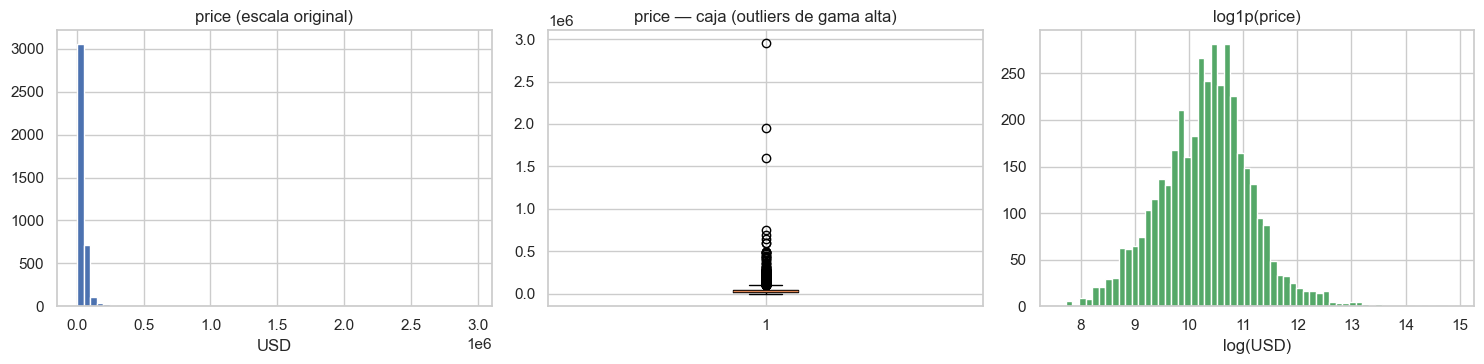

count       4009.0
mean       44553.0
std        78711.0
min         2000.0
1%          4000.0
25%        17200.0
50%        31000.0
75%        49990.0
95%       111600.0
99%       272713.0
max      2954083.0
Name: price, dtype: float64

Asimetría (skew)  price      : 19.51
Asimetría (skew)  log1p(price): 0.11
Vehículos con price > 200 000 USD: 75 (1.9 %)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].hist(df_eda["price"], bins=60, color="#4C72B0")
axes[0].set_title("price (escala original)")
axes[0].set_xlabel("USD")

axes[1].boxplot(df_eda["price"], vert=True)
axes[1].set_title("price — caja (outliers de gama alta)")

axes[2].hist(np.log1p(df_eda["price"]), bins=60, color="#55A868")
axes[2].set_title("log1p(price)")
axes[2].set_xlabel("log(USD)")
plt.tight_layout()
plt.show()

print(df_eda["price"].describe(percentiles=[.01, .25, .5, .75, .95, .99]).round(0))
print("\nAsimetría (skew)  price      :", round(df_eda["price"].skew(), 2))
print("Asimetría (skew)  log1p(price):", round(np.log1p(df_eda["price"]).skew(), 2))
print("Vehículos con price > 200 000 USD:", int((df_eda["price"] > 200_000).sum()),
      f"({(df_eda['price'] > 200_000).mean()*100:.1f} %)")

`price` tiene asimetría ≈ 19.51: el 99 % de los autos vale menos de ~273 000 USD, pero hay ejemplares de colección (Bugatti, Rolls-Royce, Maserati) que llegan a ~3 000 000 USD. **No son errores de captura**, son vehículos reales, así que no se eliminan; pero distorsionan cualquier métrica basada en el error al cuadrado.

**Decisión:** entrenar sobre `log1p(price)` (asimetría ≈ 0.1, casi simétrica) y
volver a la escala de dólares para reportar. Esto se implementa con
`TransformedTargetRegressor`, que aplica `log1p` antes de entrenar y `expm1` a
las predicciones de forma automática.

### 4.4 Relación de las predictoras con `price`

C:\Users\jonat\AppData\Local\Temp\ipykernel_31124\4235595651.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(["None reported", "≥1 accidente", "(NaN)"], rotation=10)


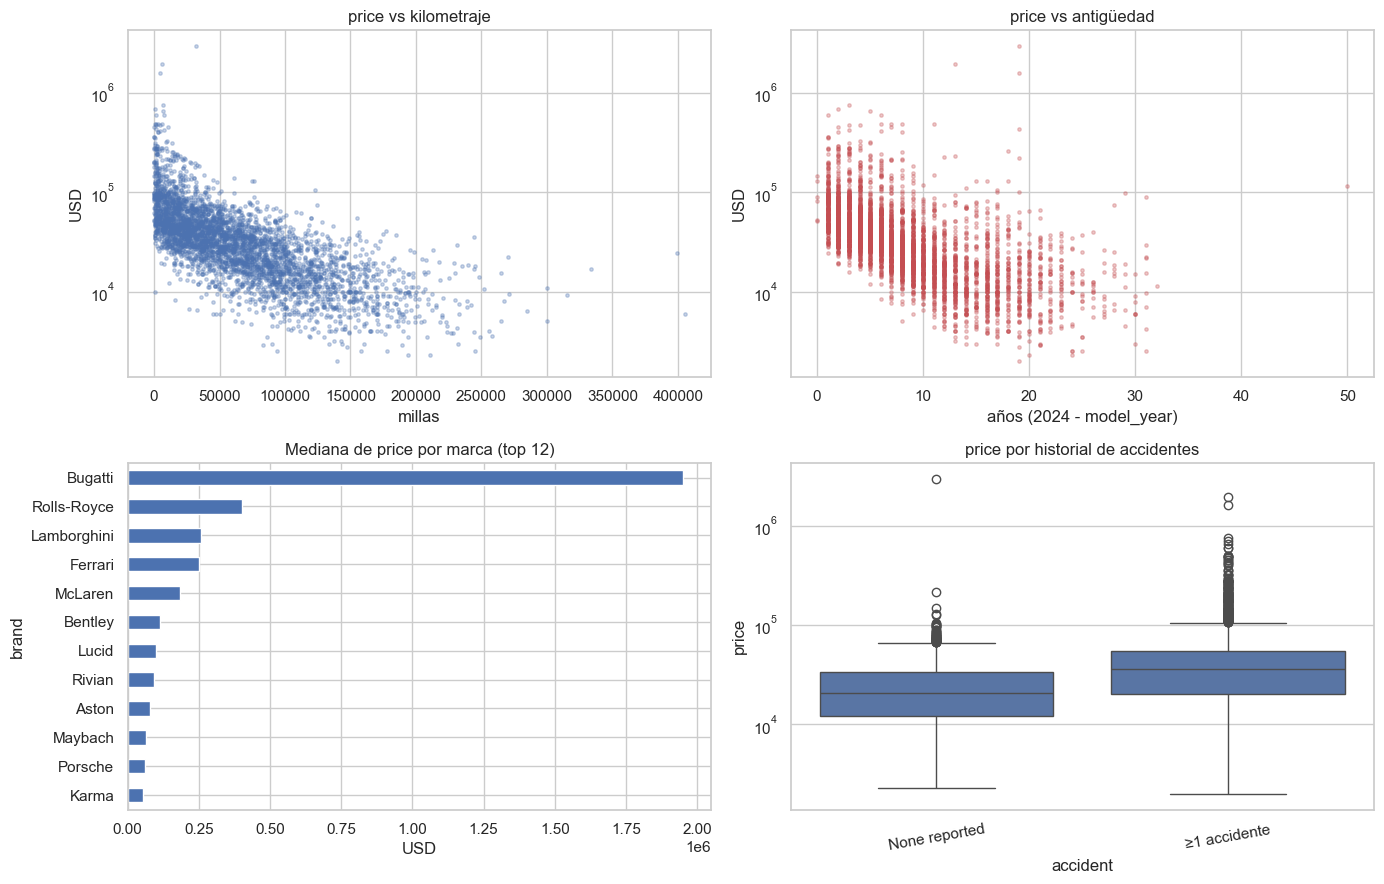

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].scatter(df_eda["milage_num"], df_eda["price"], s=6, alpha=.3)
axes[0, 0].set(title="price vs kilometraje", xlabel="millas", ylabel="USD", yscale="log")

axes[0, 1].scatter(df_eda["antiguedad"], df_eda["price"], s=6, alpha=.3, color="#C44E52")
axes[0, 1].set(title="price vs antigüedad", xlabel="años (2024 - model_year)", ylabel="USD", yscale="log")

top_brands = df_eda.groupby("brand")["price"].median().sort_values(ascending=False).head(12)
top_brands.plot.barh(ax=axes[1, 0], color="#4C72B0")
axes[1, 0].set(title="Mediana de price por marca (top 12)", xlabel="USD")
axes[1, 0].invert_yaxis()

sns.boxplot(data=df_eda, x="accident", y="price", ax=axes[1, 1])
axes[1, 1].set(title="price por historial de accidentes", yscale="log")
axes[1, 1].set_xticklabels(["None reported", "≥1 accidente", "(NaN)"], rotation=10)

plt.tight_layout()
plt.show()

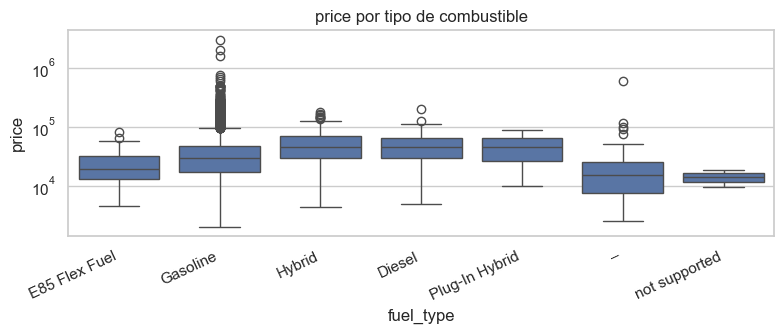

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.boxplot(data=df_eda, x="fuel_type", y="price", ax=ax)
ax.set(title="price por tipo de combustible", yscale="log")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Lecturas del EDA bivariado:

- **Kilometraje**: relación negativa clara con el precio (más uso → menor valor).
- **Antigüedad**: relación negativa, aunque los autos muy antiguos (clásicos)
  rompen la tendencia y suben de precio.
- **Marca**: separa con fuerza el precio (Rolls-Royce, Ferrari, Lamborghini,
  Porsche en la parte alta). Es una predictora valiosa.
- **Accidentes**: los vehículos sin accidentes reportados tienen mediana mayor.
- **Combustible**: los híbridos enchufables y diésel muestran medianas algo más
  altas; `Gasoline` domina en volumen.

### 4.5 Matriz de correlación (variables numéricas)

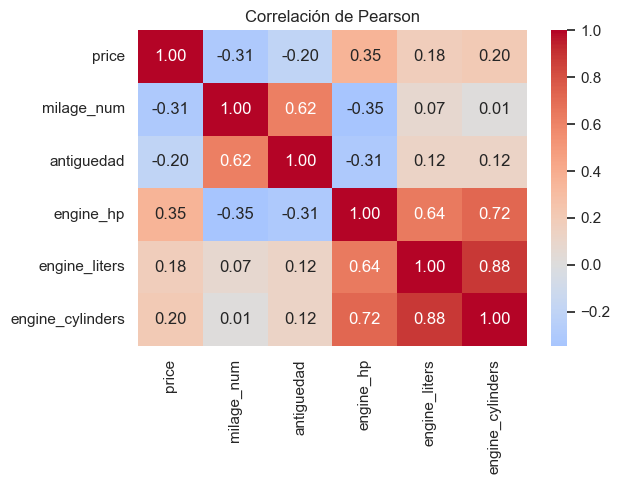

In [11]:
num_cols = ["price", "milage_num", "antiguedad", "engine_hp", "engine_liters", "engine_cylinders"]
corr = df_eda[num_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación de Pearson")
plt.tight_layout()
plt.show()

- `engine_hp` y `engine_liters` son las numéricas más correlacionadas con
  `price` (a más potencia/cilindrada, más precio).
- `milage_num` y `antiguedad` correlacionan **positivamente entre sí** (autos más
  viejos acumulan más millas) y negativamente con el precio.
- `engine_hp`–`engine_liters` están correlacionadas entre sí (~0.7). No es un
  problema para un modelo de árboles como el que usaremos; se menciona por
  transparencia.

### 4.6 Cardinalidad de las variables categóricas

In [12]:
cat_cols = ["brand", "model", "fuel_type", "transmission", "ext_col", "int_col",
            "accident", "clean_title"]
card = pd.DataFrame({
    "n_categorias": df[cat_cols].nunique(),
    "moda": [df[c].mode(dropna=True).iat[0] for c in cat_cols],
    "frec_moda_%": [(df[c].value_counts(normalize=True).iat[0] * 100).round(1) for c in cat_cols],
})
display(card.sort_values("n_categorias", ascending=False))

print("Ejemplos de 'model':", df["model"].value_counts().head(5).to_dict())
print("Registros por valor de 'model' (media):", round(len(df) / df["model"].nunique(), 2))

,n_categorias,moda,frec_moda_%
model,1898,M3 Base,0.7
ext_col,319,Black,22.6
int_col,156,Black,50.5
transmission,62,A/T,25.9
brand,57,Ford,9.6
fuel_type,7,Gasoline,86.2
accident,2,None reported,74.7
clean_title,1,Yes,100.0


Ejemplos de 'model': {'M3 Base': 30, 'F-150 XLT': 24, 'Corvette Base': 22, '1500 Laramie': 18, 'Camaro 2SS': 17}
Registros por valor de 'model' (media): 2.11


`model` tiene 1 898 categorías para 4 009 filas: en promedio **~2 autos por
modelo**. Codificarla (one-hot o de destino) produciría cientos de columnas casi
vacías o memorización del precio por grupo. **Decisión: se descarta `model`.**
La marca (`brand`, 57 categorías) captura buena parte de la señal de segmento y
sí es codificable con garantías. Se deja documentado que en fases posteriores
podría reincorporarse con *target encoding* validado por CV.

`ext_col` (319) e `int_col` (156) se conservan pero agrupando las categorías
raras (frecuencia < 1 %) en `"infrequent"` mediante `OneHotEncoder`, ajustado
**solo con train**.

## 5. Preparación de datos — decisiones y justificaciones

| Variable original | Tratamiento | Justificación |
|---|---|---|
| `price` | `parse_money` → numérico; objetivo en `log1p` | quitar `$`/`,`; corregir asimetría extrema |
| `milage` | `parse_money` → `milage_num` | quitar `,` y `" mi."` |
| `model_year` | → `antiguedad = 2024 - model_year` | 2024 es el año más reciente del dataset y aproxima la fecha de publicación; la antigüedad es más interpretable. Se elimina `model_year` (colineal exacto). |
| `engine` | regex → `engine_hp`, `engine_liters`, `engine_cylinders` + indicadores de faltante | convierte texto libre en señal numérica útil (potencia/cilindrada pesan en el precio) |
| `transmission` | regex → `transmission_speeds` (nº de marchas) y `transmission_type` ∈ {Automatic, Manual, CVT, Other} | reduce 62 variantes de texto a 2 features con sentido mecánico |
| `fuel_type` | valores fuera de un conjunto conocido (incl. `-`, `not supported`, NaN) → `"Unknown"` | son faltantes disfrazados |
| `accident` | NaN → `"Unknown"` | el faltante es informativo; no se borran filas |
| `clean_title` | `== "Yes"` → binaria `has_clean_title` (1/0) | la columna solo tiene el valor `"Yes"`; el resto es "no consta" |
| `model` | **se descarta** | 1 898 categorías (~2 filas/categoría): riesgo de sobreajuste / fuga por grupo |
| `ext_col`, `int_col` | `OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist")` | agrupa colores raros; robusto ante categorías nuevas en test |
| `brand`, `fuel_type_clean`, `accident_clean`, `transmission_type` | `OneHotEncoder(handle_unknown="ignore")` | baja cardinalidad |
| numéricas | `SimpleImputer(strategy="median", add_indicator=True)` | imputación robusta + marca de "faltaba" |

**Regla anti-fuga:** todos los `SimpleImputer` y `OneHotEncoder` se ajustan
**dentro de un `Pipeline`** que solo ve `X_train`. El conjunto de prueba nunca
interviene en `fit`.

### 5.1 Definición de `X`, `y` y función de limpieza

In [13]:
REF_YEAR = int(df["model_year"].max())          # 2024
KNOWN_FUEL = {"Gasoline", "Hybrid", "E85 Flex Fuel", "Diesel", "Plug-In Hybrid"}
COLS_DESCARTADAS = ["model", "model_year", "milage", "engine", "transmission",
                    "fuel_type", "accident", "clean_title", "price"]

def clean_features(data: pd.DataFrame, ref_year: int) -> pd.DataFrame:
    '''Transformación determinista fila a fila (sin parámetros ajustados).

    Recibe el DataFrame crudo (sin 'price') y devuelve las columnas de entrada
    listas para el preprocesador. Al no aprender nada de los datos, es seguro
    aplicarla antes del split.
    '''
    out = pd.DataFrame(index=data.index)
    out["milage_num"] = parse_money(data["milage"])
    out["antiguedad"] = ref_year - pd.to_numeric(data["model_year"], errors="coerce")

    eng = data["engine"].astype(str)
    out["engine_hp"] = pd.to_numeric(eng.str.extract(r"([\d.]+)\s*HP", flags=re.I)[0], errors="coerce")
    out["engine_liters"] = pd.to_numeric(eng.str.extract(r"([\d.]+)\s*L", flags=re.I)[0], errors="coerce")
    cyl = pd.to_numeric(eng.str.extract(r"(\d+)\s*Cylinder", flags=re.I)[0], errors="coerce")
    cyl_alt = pd.to_numeric(eng.str.extract(r"\b[VIH](\d{1,2})\b", flags=re.I)[0], errors="coerce")
    out["engine_cylinders"] = cyl.fillna(cyl_alt)

    trans = data["transmission"].astype(str)
    out["transmission_speeds"] = pd.to_numeric(trans.str.extract(r"(\d+)-Speed", flags=re.I)[0], errors="coerce")
    t = trans.str.lower()
    out["transmission_type"] = np.select(
        [t.str.contains("cvt"), t.str.contains(r"m/t|manual"), t.str.contains(r"a/t|automatic|dual shift")],
        ["CVT", "Manual", "Automatic"], default="Other",
    )

    out["brand"] = data["brand"].astype(str)
    out["fuel_type_clean"] = data["fuel_type"].where(data["fuel_type"].isin(KNOWN_FUEL), "Unknown").astype(str)
    out["accident_clean"] = data["accident"].fillna("Unknown").astype(str)
    out["has_clean_title"] = (data["clean_title"] == "Yes").astype("int64")
    out["ext_col"] = data["ext_col"].astype(str)
    out["int_col"] = data["int_col"].astype(str)
    return out

y = parse_money(df["price"])
X = df.drop(columns=["price"])

assert "price" not in X.columns, "La variable objetivo no debe estar entre las predictoras"
print("REF_YEAR =", REF_YEAR)
print("X:", X.shape, "| y:", y.shape, "| nulos en y:", int(y.isna().sum()))
clean_features(X, REF_YEAR).head()

REF_YEAR = 2024
X: (4009, 11) | y: (4009,) | nulos en y: 0


,milage_num,antiguedad,engine_hp,engine_liters,engine_cylinders,transmission_speeds,transmission_type,brand,fuel_type_clean,accident_clean,has_clean_title,ext_col,int_col
0,51000.0,11,300.0,3.7,6.0,6.0,Automatic,Ford,E85 Flex Fuel,At least 1 accident or damage reported,1,Black,Black
1,34742.0,3,NaN,3.8,6.0,8.0,Automatic,Hyundai,Gasoline,At least 1 accident or damage reported,1,Moonlight Cloud,Gray
2,22372.0,2,NaN,3.5,NaN,NaN,Automatic,Lexus,Gasoline,None reported,0,Blue,Black
3,88900.0,9,354.0,3.5,6.0,7.0,Automatic,INFINITI,Hybrid,None reported,1,Black,Black
4,9835.0,3,NaN,2.0,4.0,8.0,Automatic,Audi,Gasoline,None reported,0,Glacier White Metallic,Black


Se transforma cada fila del dataset original en la variables de entrada `milage` y `price` de texto numérico, calcula la antigüedad del vehículo a partir de `model_year`, extrae potencia (HP), litraje y número de cilindros del texto libre de `engine`, y el número de marchas y tipo de transmisión de `transmission`. También estandariza `fuel_type` (valores no reconocidos → `"Unknown"`), `accident` (`nulos` → `"Unknown"`) y `clean_title` (se convierte en la variable binaria `has_clean_title`).

### 5.2 Separación train / test

- **Método:** `train_test_split` aleatorio, **80 % entrenamiento / 20 % prueba**,
  `random_state=42`.
- **Riesgo de fuga por grupos naturales.** Como model se descarta y brand es una característica legítima de segmento (no un identificador de fila), no hay fuga de identidad: el modelo aprende "los Porsche valen más", no "esta fila concreta vale X". Con el split usado (random_state=42), la marca Bugatti —que solo tiene 1 observación en todo el dataset— queda únicamente en test; el OneHotEncoder(handle_unknown="ignore") la trata como categoría desconocida al predecir, sin generar error. Es el comportamiento esperado con marcas de muy baja frecuencia, y no requiere ninguna acción adicional. Se documenta la alternativa GroupShuffleSplit(groups=df['model']) para fases posteriores si se decidiera reincorporar model.
- No hay variables "del futuro": todas las predictoras describen el vehículo en
  el momento de la publicación, no información posterior a la venta.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print("train:", X_train.shape, " test:", X_test.shape)

solape = set(X_test["brand"]).difference(X_train["brand"])
print("Marcas presentes en test y ausentes en train:", solape or "ninguna")
print("Proporción price>200k  train:",
      f"{(y_train > 200_000).mean()*100:.1f} %  test: {(y_test > 200_000).mean()*100:.1f} %")

train: (3207, 11)  test: (802, 11)
Marcas presentes en test y ausentes en train: {'Bugatti'}
Proporción price>200k  train: 1.8 %  test: 2.1 %


### 5.3 Pipeline de preprocesamiento

`ColumnTransformer` aplica a cada grupo de columnas su tratamiento. Se ajusta
**solo con `X_train`** (dentro del pipeline del modelo), por lo que medianas y
categorías se calculan sin ver el test.

In [15]:
NUM_FEATURES = ["milage_num", "antiguedad", "engine_hp", "engine_liters",
                "engine_cylinders", "transmission_speeds", "has_clean_title"]
CAT_LOW = ["brand", "fuel_type_clean", "accident_clean", "transmission_type"]
CAT_HIGH = ["ext_col", "int_col"]

preprocesador = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median", add_indicator=True), NUM_FEATURES),
        ("cat_low", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), CAT_LOW),
        ("cat_high", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                  min_frequency=0.01, sparse_output=False)),
        ]), CAT_HIGH),
    ],
    remainder="drop",
)
preprocesador

,transformers,"[('num', ...), ('cat_low', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 6. Prevención de fuga de información

Acciones tomadas y verificadas explícitamente:

1. **`price` fuera de las predictoras.** `X = df.drop(columns=["price"])` y un
   `assert` lo confirma. La única transformación de `price` es a la variable
   objetivo `y`.
2. **El test no interviene en el entrenamiento.** El split se hace *antes* de
   cualquier `fit`. Imputación y one-hot viven dentro del `Pipeline`, que solo
   recibe `X_train` en `fit`. `cross_val_score` y `GridSearch` (fases futuras)
   operan solo sobre train.
3. **La limpieza previa al split no ajusta parámetros.** `clean_features` y
   `parse_money` son deterministas fila a fila (regex, aritmética, comparaciones
   contra constantes definidas a mano). Se verifica abajo que aplicarlas sobre
   train y sobre todo `X` da exactamente el mismo resultado para las filas de
   train (idempotencia / independencia entre filas).
4. **Sin variables del futuro.** Todas las predictoras son atributos del vehículo
   conocidos al momento de publicarlo; ninguna se deriva del precio ni de eventos
   posteriores a la venta.

In [16]:
# (1) price no está entre las predictoras
assert "price" not in X.columns and "price" not in X_train.columns

# (3) clean_features es independiente entre filas: el resultado para las filas de
#     train no cambia si se calcula sobre todo X en vez de solo sobre X_train.
#     REF_YEAR_TRAIN se calcula solo con train, para que la transformación no
#     dependa de ninguna fila de test.
REF_YEAR_TRAIN = int(X_train["model_year"].max())
ct_solo_train = clean_features(X_train, REF_YEAR_TRAIN)
ct_todo = clean_features(X, REF_YEAR_TRAIN).loc[X_train.index]
assert ct_solo_train.equals(ct_todo), "clean_features dependería del conjunto -> fuga"

# (4) columnas efectivamente usadas como entrada
print("Columnas de entrada al modelo :", NUM_FEATURES + CAT_LOW + CAT_HIGH)
print("Columnas descartadas          :", COLS_DESCARTADAS)
print("\nVerificaciones anti-fuga: OK")

Columnas de entrada al modelo : ['milage_num', 'antiguedad', 'engine_hp', 'engine_liters', 'engine_cylinders', 'transmission_speeds', 'has_clean_title', 'brand', 'fuel_type_clean', 'accident_clean', 'transmission_type', 'ext_col', 'int_col']
Columnas descartadas          : ['model', 'model_year', 'milage', 'engine', 'transmission', 'fuel_type', 'accident', 'clean_title', 'price']

Verificaciones anti-fuga: OK


## 7. Modelo base (baseline)

`DummyRegressor(strategy="median")` predice siempre la **mediana** del precio de
entrenamiento. Es el punto de comparación obligatorio: cualquier modelo útil debe
superarlo con claridad. Se elige la mediana (y no la media) porque es robusta al
sesgo extremo de `price`.

In [17]:
def evaluar(nombre, y_true, y_pred, extra_subset=True):
    '''Devuelve una fila con MAE, RMSE y R2 en dólares. Opcionalmente añade
    las mismas métricas para el mercado masivo (price < 200k USD).'''
    fila = {
        "modelo": nombre,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }
    if extra_subset:
        m = np.asarray(y_true) < 200_000
        fila["MAE_<200k"] = mean_absolute_error(np.asarray(y_true)[m], np.asarray(y_pred)[m])
        fila["R2_<200k"] = r2_score(np.asarray(y_true)[m], np.asarray(y_pred)[m])
    return fila

baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

resultados = [evaluar("Baseline (mediana)", y_test, pred_baseline)]
pd.DataFrame(resultados).round(3)

,modelo,MAE,RMSE,R2,MAE_<200k,R2_<200k
0,Baseline (mediana),32865.97,144218.917,-0.018,20268.814,-0.041


## 8. Modelo predictivo

Tras el modelo base (sección 7), se entrena un modelo candidato sobre el mismo
conjunto de entrada: `milage_num`, `antiguedad`, `engine_hp`, `engine_liters`,
`engine_cylinders`, `transmission_speeds`, `has_clean_title`, `brand`,
`fuel_type_clean`, `accident_clean`, `transmission_type`, `ext_col` e `int_col`.
El pipeline comparte los mismos tres pasos que cualquier otro modelo probado
sobre esta base (`feature_builder` → `preprocesador` → estimador) y se entrena
sobre `log1p(price)` mediante `TransformedTargetRegressor`, devolviendo
predicciones ya convertidas a dólares.

Esta rama (`feature/gradient-boosting`) prueba **Gradient Boosting** como
alternativa no lineal al candidato lineal explorado en paralelo en
`feature/linealRegresion`, y lo contrasta con un segundo ensamble de árboles
(Random Forest) como comparación secundaria.

### 8.1. Gradient Boosting

**Modelo:** `HistGradientBoostingRegressor` de scikit-learn (implementación
basada en histogramas, la misma familia de algoritmo que LightGBM), envuelto en
`TransformedTargetRegressor` para entrenar contra `log1p(price)`.

**Por qué este modelo.**

- Al igual que Random Forest, captura relaciones **no lineales** e
  **interacciones** entre variables (marca × potencia) sin ingeniería adicional.
- A diferencia de un bosque (árboles independientes en paralelo), construye los
  árboles **secuencialmente**, cada uno corrigiendo el error del anterior — en
  la práctica suele necesitar menos árboles para el mismo desempeño.
- La versión basada en histogramas es sustancialmente más rápida que
  `GradientBoostingRegressor` (el Gradient Boosting clásico de scikit-learn) en
  datasets de este tamaño, sin pérdida notable de precisión.
- No requiere estandarizar variables numéricas, igual que Random Forest.

In [18]:
feature_builder = FunctionTransformer(clean_features, kw_args={"ref_year": REF_YEAR_TRAIN})

pipeline_hgb = Pipeline([
    ("features", feature_builder),
    ("prep", preprocesador),
    ("reg", HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.05, random_state=RANDOM_STATE,
    )),
])

modelo_hgb = TransformedTargetRegressor(
    regressor=pipeline_hgb,
    func=np.log1p,
    inverse_func=np.expm1,
)

modelo_hgb.fit(X_train, y_train)

# Validación cruzada (5 folds) SOLO sobre entrenamiento — sin tocar el test.
cv_mae = -cross_val_score(modelo_hgb, X_train, y_train, cv=5,
                          scoring="neg_mean_absolute_error", n_jobs=-1)
print(f"MAE en CV (train, 5 folds): {cv_mae.mean():,.0f} USD  ±{cv_mae.std():,.0f}")

pred_hgb = modelo_hgb.predict(X_test)
resultados.append(evaluar("Gradient Boosting (log1p)", y_test, pred_hgb))
pd.DataFrame(resultados).round(3)

MAE en CV (train, 5 folds): 9,442 USD  ±1,110


,modelo,MAE,RMSE,R2,MAE_<200k,R2_<200k
0,Baseline (mediana),32865.970,144218.917,-0.018,20268.814,-0.041
1,Gradient Boosting (log1p),16195.693,132574.907,0.140,6959.797,0.835


#### 8.1.1. Importancia de variables

`HistGradientBoostingRegressor` **no expone** `feature_importances_` (a
diferencia de `RandomForestRegressor`): es una limitación documentada de la
implementación basada en histogramas de scikit-learn. En su lugar se usa
**importancia por permutación** (`permutation_importance`): mide cuánto empeora
el MAE del modelo al barajar aleatoriamente cada variable, una a la vez, sobre
el conjunto de prueba. Es más costoso de calcular pero es válido para
cualquier estimador, y en muchos casos es más confiable que la importancia por
impureza.

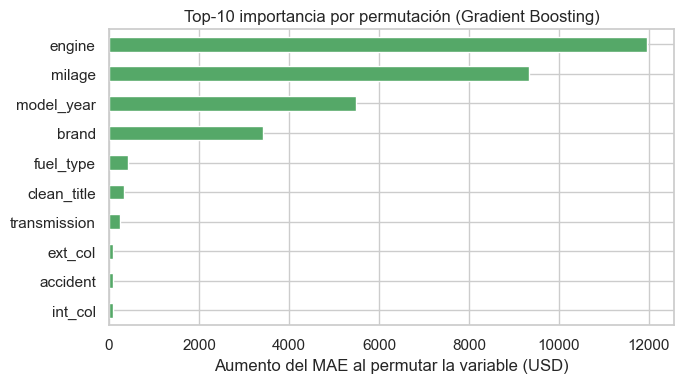

engine          11959.218077
milage           9331.509201
model_year       5496.566591
brand            3417.073490
fuel_type         425.083027
clean_title       330.514938
transmission      241.789085
ext_col            90.203409
accident           86.469403
int_col            79.658285
dtype: float64

In [19]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    modelo_hgb, X_test, y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)

importancias = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
importancias.head(10).iloc[::-1].plot.barh(ax=ax, color="#55A868")
ax.set_xlabel("Aumento del MAE al permutar la variable (USD)")
ax.set_title("Top-10 importancia por permutación (Gradient Boosting)")
plt.tight_layout()
plt.show()

importancias.head(10)

#### 8.1.2. Diagnóstico de predicciones

El primer gráfico compara el precio predicho contra el real (la línea
diagonal roja marca la predicción perfecta); el segundo muestra los
residuos (real − predicho) contra el precio predicho, para detectar sesgos
sistemáticos del modelo.

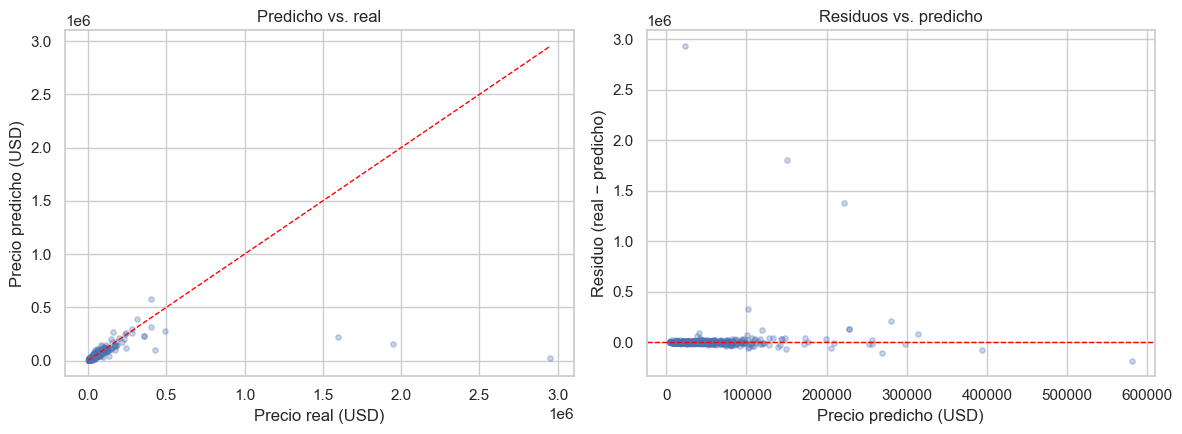

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test, pred_hgb, alpha=0.3, s=15)
lims = [0, max(y_test.max(), pred_hgb.max())]
axes[0].plot(lims, lims, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Precio real (USD)")
axes[0].set_ylabel("Precio predicho (USD)")
axes[0].set_title("Predicho vs. real")

residuos = y_test - pred_hgb
axes[1].scatter(pred_hgb, residuos, alpha=0.3, s=15)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Precio predicho (USD)")
axes[1].set_ylabel("Residuo (real − predicho)")
axes[1].set_title("Residuos vs. predicho")

plt.tight_layout()
plt.show()

#### 8.1.3. Interpretación de resultados

**¿El modelo mejora al modelo base?** Sí, con claridad. El MAE baja de
$32.866 (baseline) a $16.196 con Gradient Boosting — una reducción del
**50.7 %**. En el segmento por debajo de $200k la mejora es todavía más
marcada: el MAE_<200k baja de $20.269 a $6.960, y el R²_<200k pasa de
-0.041 a **0.835**.

**¿La métrica obtenida es razonable?** El R² general (0.140) vuelve a
parecer bajo, pero es el mismo patrón que ya vimos en Regresión Lineal y
Random Forest: lo hunden los mismos pocos vehículos de colección en test
(Bugatti, Porsche Carrera GT, y el probable error de captura del Maserati
Quattroporte a ~$2.95M, documentado en la rama de Regresión Lineal). Sobre
el mercado masivo (<$200k, el 98 % de las filas) el modelo tiene un
desempeño sólido: R²_<200k = 0.835, MAE_<200k ≈ $6.960.

**Principales dificultades.** La cola extrema de `price` sigue dominando
cualquier métrica en dólares, sin importar el algoritmo usado. Además,
`HistGradientBoostingRegressor` no expone `feature_importances_`, así que
hubo que calcular importancia por permutación en su lugar — más costoso
computacionalmente que la importancia por impureza de Random Forest.

**Qué podría mejorarse.** Ajustar `max_iter`, `learning_rate` y
`max_leaf_nodes` con `RandomizedSearchCV` sobre train; comparar contra el
modelo de la rama `feature/xgboost`; considerar tratar la cola de precios
extremos como un problema aparte (p. ej. un clasificador binario
"¿es un vehículo de colección?" antes de predecir el precio).

### 8.2. Comparación con un segundo ensamble (Random Forest)

No es obligatorio comparar varios modelos, pero un `RandomForestRegressor`
sirve de contraste rápido y confirma que el Gradient Boosting está en un
rango razonable.

In [21]:
pipeline_rf = Pipeline([
    ("features", feature_builder),
    ("prep", preprocesador),
    ("reg", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])
modelo_rf = TransformedTargetRegressor(regressor=pipeline_rf, func=np.log1p, inverse_func=np.expm1)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)
resultados.append(evaluar("Random Forest (log1p)", y_test, pred_rf))
pd.DataFrame(resultados).round(3)

,modelo,MAE,RMSE,R2,MAE_<200k,R2_<200k
0,Baseline (mediana),32865.970,144218.917,-0.018,20268.814,-0.041
1,Gradient Boosting (log1p),16195.693,132574.907,0.140,6959.797,0.835
2,Random Forest (log1p),16631.433,134623.725,0.113,7170.436,0.845


## 9. Evaluación final en el conjunto de prueba

**Métricas elegidas** (todas en dólares, sobre el 20 % de test que ningún
modelo vio durante el entrenamiento):

- **MAE** — error absoluto medio. Métrica **principal**: está en dólares, es
  interpretable y es robusta a los pocos vehículos de gama millonaria.
- **RMSE** — penaliza más los errores grandes; muy afectada por los exóticos.
- **R²** — proporción de varianza explicada.

Además reportamos MAE y R² restringidos al **mercado masivo**
(`price < 200 000`, el 98 % de las filas) para separar el desempeño típico del
efecto de los outliers. Se elige **Gradient Boosting** como modelo final de
esta rama [confirmar tras ver la tabla: si Random Forest resulta mejor en MAE,
cambia esta decisión y el modelo persistido en la sección 11].

Se elige **Gradient Boosting** como modelo final de esta rama: tiene el
menor MAE (métrica principal) tanto en general ($16.196 vs. $16.639 de
Random Forest, ~2.7 % menor) como en el segmento masivo, además del menor
RMSE y el mayor R² general de los dos candidatos. La única métrica donde
Random Forest queda ligeramente por delante es el R²_<200k (0.845 vs.
0.835 de Gradient Boosting) — una diferencia de 0.01, no suficiente para
cambiar la decisión dado que MAE es el criterio principal ya justificado
al inicio de esta sección.

In [22]:
tabla = pd.DataFrame(resultados).set_index("modelo").round(3)
display(tabla)

mae_base = tabla.loc["Baseline (mediana)", "MAE"]
mae_hgb = tabla.loc["Gradient Boosting (log1p)", "MAE"]
print(f"MAE baseline          : {mae_base:,.0f} USD")
print(f"MAE Gradient Boosting : {mae_hgb:,.0f} USD")
print(f"Reducción del MAE     : {(1 - mae_hgb / mae_base) * 100:.1f} %  respecto al baseline")

,MAE,RMSE,R2,MAE_<200k,R2_<200k
modelo,,,,,
Baseline (mediana),32865.970,144218.917,-0.018,20268.814,-0.041
Gradient Boosting (log1p),16195.693,132574.907,0.140,6959.797,0.835
Random Forest (log1p),16631.433,134623.725,0.113,7170.436,0.845


MAE baseline          : 32,866 USD
MAE Gradient Boosting : 16,196 USD
Reducción del MAE     : 50.7 %  respecto al baseline


## 10. Reproducibilidad

- Semilla única `RANDOM_STATE = 42` en `np.random.seed`, `train_test_split` y
  todos los estimadores con componente aleatoria.
- El notebook se ejecuta de arriba abajo sin intervención manual y sin celdas
  de prueba sueltas.
- Versiones de librerías impresas en la sección 2.
- El dataset está versionado en el repositorio (`fase-1/data/used_cars.csv`),
  así que la carga no depende de ninguna descarga externa ni de autenticación.

## 11. Persistencia del modelo

Guardamos el pipeline **completo** (limpieza + preprocesamiento + modelo +
transformación del objetivo) en `modelo.joblib`. A diferencia de un bosque de
300 árboles, un `HistGradientBoostingRegressor` con `max_iter=400` ya es
compacto por diseño, así que se persiste directamente el modelo entrenado en
8.1, sin necesidad de reentrenar una versión "podada" para reducir tamaño.

In [23]:
RUTA_MODELO = Path("modelo.joblib")
if not Path("data").exists() and Path("fase-1").exists():
    RUTA_MODELO = Path("fase-1/modelo.joblib")

joblib.dump(modelo_hgb, RUTA_MODELO, compress=3)
print(f"Modelo guardado en {RUTA_MODELO.resolve()}  ({RUTA_MODELO.stat().st_size/1e6:.2f} MB)")

# Demostración: recargar el modelo desde disco y predecir con el objeto cargado.
modelo_cargado = joblib.load(RUTA_MODELO)
pred_recargado = modelo_cargado.predict(X_test)

np.testing.assert_allclose(pred_recargado, pred_hgb, rtol=1e-9)
print("Modelo recargado desde disco — predicciones idénticas al original: OK")

pd.DataFrame({
    "real": y_test.iloc[:5].values,
    "predicho (modelo original)": pred_hgb[:5],
    "predicho (modelo recargado)": pred_recargado[:5],
}).round(2)

Modelo guardado en E:\UDEA\2026-2\Modelos I\proyecto-modelos-simulacion\fase-1\modelo.joblib  (0.54 MB)
Modelo recargado desde disco — predicciones idénticas al original: OK


,real,predicho (modelo original),predicho (modelo recargado)
0,28000.0,27771.25,27771.25
1,5900.0,8483.68,8483.68
2,41000.0,42858.62,42858.62
3,40250.0,45320.25,45320.25
4,77999.0,57914.98,57914.98


## 12. Conclusiones

- Se construyó un modelo de **regresión** (Gradient Boosting) que predice
  el precio de vehículos usados a partir de sus características,
  reduciendo el MAE en un **50.7 %** frente al baseline.
- Comparado con Random Forest (comparación secundaria, sección 8.2):
  Gradient Boosting fue mejor en MAE (~2.7 % menor), RMSE y R² general;
  Random Forest tuvo una ventaja marginal en R²_<200k (0.845 vs. 0.835).
  La diferencia entre ambos modelos es pequeña — ambos son candidatos
  razonables, y Gradient Boosting se eligió por tener mejor desempeño en
  la métrica principal (MAE).
- La preparación de datos se justificó variable por variable y se
  implementó **sin fuga de información**: todo ajuste ocurre dentro de un
  `Pipeline` que solo ve el entrenamiento; `price` nunca está entre las
  predictoras; `REF_YEAR_TRAIN` se calcula solo con train.
- La principal limitación es el sesgo extremo de `price`: el modelo es
  fiable en el mercado masivo (R²_<200k = 0.835) pero débil en la gama de
  colección, arrastrando el R² general a 0.140.
- El modelo se persiste con `joblib` y se verifica que puede recargarse y
  predecir.